In [ ]:
import seaborn as sns
import matplotlib as plt
from newutils.plots import TSPlotter

In [ ]:
class TSPlotStyle:
    def __init__(self, context="paper", style="darkgrid", palette="Set2"):
        self._ctx = sns.plotting_context(context)
        self._sty = sns.axes_style(style)
        self._pal = sns.color_palette(palette)

    def __enter__(self):
        self._ctx.__enter__()
        self._sty.__enter__()
        self._pal.__enter__()
        return None

    def __exit__(self, exc_type, exc_val, exc_tb):
        self._pal.__exit__(exc_type, exc_val, exc_tb)
        self._sty.__exit__(exc_type, exc_val, exc_tb)
        self._ctx.__exit__(exc_type, exc_val, exc_tb)

'mape_vs_pseudo_mape.pdf'

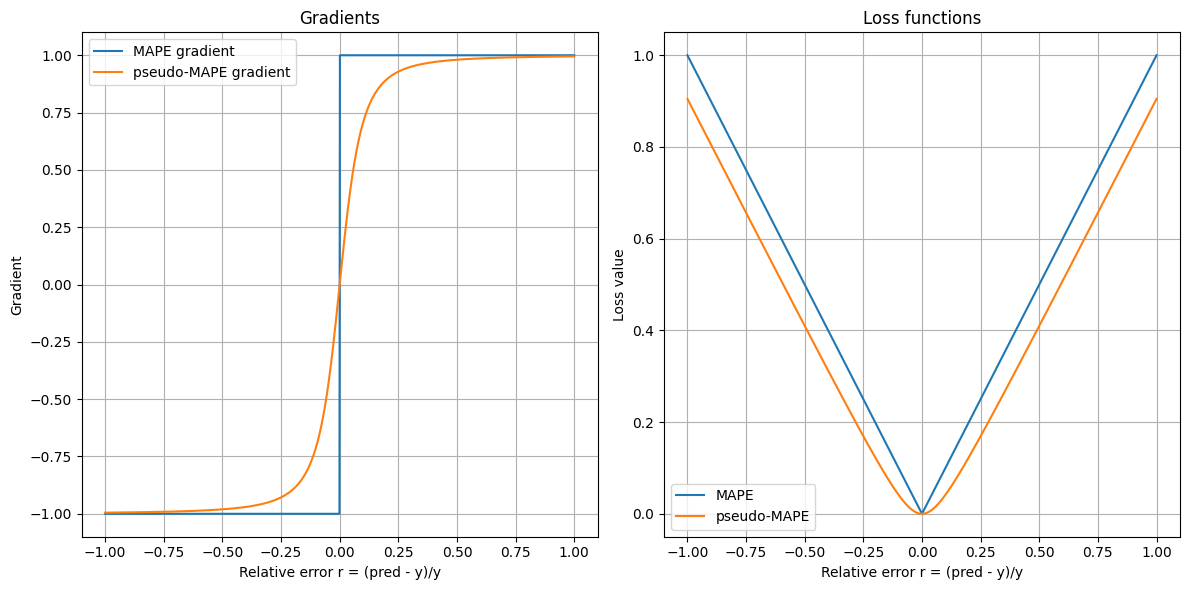

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Define r (relative error) range
r = np.linspace(-1, 1, 1000)
delta = 0.1

# Functions
mape = np.abs(r)
pseudo_mape = np.sqrt(r**2 + delta**2) - delta

# Gradients (w.r.t. prediction, assuming y = 1)
grad_mape = np.sign(r)
grad_mape[np.isclose(r, 0)] = 0  # define at zero for plotting
grad_pseudo = r / np.sqrt(r**2 + delta**2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: gradients
axes[0].plot(r, grad_mape, label="MAPE gradient")
axes[0].plot(r, grad_pseudo, label="pseudo-MAPE gradient")
axes[0].set_xlabel("Relative error r = (pred - y)/y")
axes[0].set_ylabel("Gradient")
axes[0].set_title("Gradients")
axes[0].legend()
axes[0].grid(True)

# Right: functions
axes[1].plot(r, mape, label="MAPE")
axes[1].plot(r, pseudo_mape, label="pseudo-MAPE")
axes[1].set_xlabel("Relative error r = (pred - y)/y")
axes[1].set_ylabel("Loss value")
axes[1].set_title("Loss functions")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

file_path = 'mape_vs_pseudo_mape.pdf'
plt.savefig(file_path, format='pdf')

file_path
